In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import os
file_path ='/content/drive/MyDrive/Telco_Churn_Dataset/Telco-Customer-Churn_converted.csv'
print("File exists:", os.path.exists(file_path))

File exists: True


In [37]:
df = pd.read_csv(file_path)
print("Shape: ", df.shape)

Shape:  (7043, 21)


In [38]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== Blank Spaces (hidden missing values)===")
print((df=='').sum())

=== NULL VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== Blank Spaces (hidden missing values)===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               

In [41]:
print("Umique problematic values in TotalCharges:")
print(df[df['TotalCharges'].str.strip()== '']['TotalCharges'].count())

print("\nSample of rows where TotalCharges is blank:")
print(df[df['TotalCharges'].str.strip()==''][['customerID','tenure','MonthlyCharges','TotalCharges']])

Umique problematic values in TotalCharges:
11

Sample of rows where TotalCharges is blank:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [42]:
df['TotalCharges'] = df['TotalCharges'].str.strip()
df['TotalCharges'] = df['TotalCharges'].replace('','0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

print(df[df['tenure']==0][['customerID','tenure','MonthlyCharges','TotalCharges']].head())

      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           0.0
753   3115-CZMZD       0           20.25           0.0
936   5709-LVOEQ       0           80.85           0.0
1082  4367-NUYAO       0           25.75           0.0
1340  1371-DWPAZ       0           56.05           0.0


In [43]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("SeniorCitizen unique values: ", df['SeniorCitizen'].unique())

SeniorCitizen unique values:  ['No' 'Yes']


In [44]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [46]:
# STEP 13 — Check unique values in categorical columns
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
SeniorCitizen: ['No' 'Yes']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [47]:
def tenure_group(tenure):
  if tenure <= 12:
    return '0-12 Months'
  elif tenure <= 24:
    return '12-24 Months'
  elif tenure <= 48:
    return '24-48 Months'
  else:
    return '48+ Months'

df['tenure_group'] = df['tenure'].apply(tenure_group)

print(df['tenure_group'].value_counts())

tenure_group
48+ Months      2239
0-12 Months     2186
24-48 Months    1594
12-24 Months    1024
Name: count, dtype: int64


In [48]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Cleaned Data View ===")
df.head()

=== Shape ===
(7043, 22)

=== Data Types ===
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_group         object
dtype: object

=== Cleaned Data View ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,24-48 Months
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,24-48 Months
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


In [49]:
# STEP 16 — Save cleaned data to Google Drive
cleaned_path = '/content/drive/MyDrive/Telco_Churn_Dataset/telco_churn_cleaned.csv'
df.to_csv(cleaned_path, index=False)
print("Cleaned data saved successfully!")
print("Location:", cleaned_path)

Cleaned data saved successfully!
Location: /content/drive/MyDrive/Telco_Churn_Dataset/telco_churn_cleaned.csv


In [50]:
# ============= Exploratory Data Analysis =============

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['font.size'] = 12



=== Churn Counts ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Churn Percentage ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


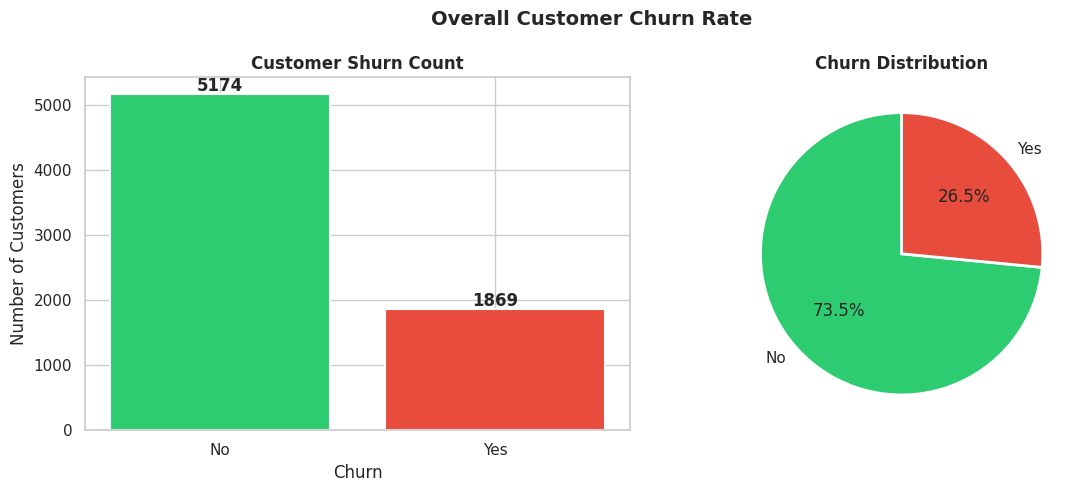

In [51]:
# Overall Churn Rate
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== Churn Counts ===")
print(churn_counts)
print("\n=== Churn Percentage ===")
print(churn_pct.round(2))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

ax1.bar(churn_counts.index, churn_counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=1.5)
ax1.set_title('Customer Shurn Count', fontweight='bold')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
  ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

ax2.pie(churn_counts.values, labels=churn_counts.index,
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Churn Distribution', fontweight='bold')

plt.suptitle('Overall Customer Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q1_churn_rate.png',
            dpi=150, bbox_inches='tight')
plt.show()


Analysis 1: Overall Churn Rate

26.54% of customers have churned — that is 1,869 out of 7,043 customers.
Industry average churn for telecom is 15-20%.
This company is significantly above average, meaning retention is a serious
business problem that needs immediate attention.

=== Churn Rate by Contract Type ===
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


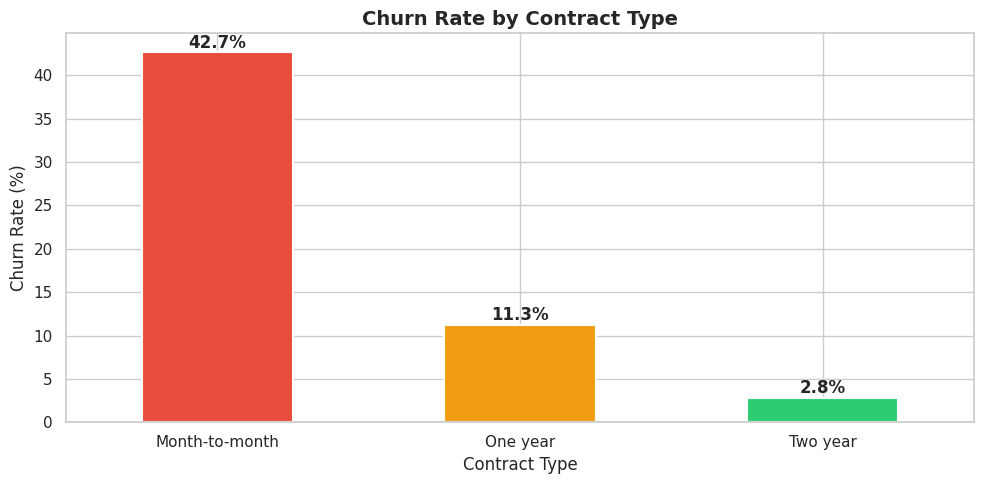

In [52]:
# Which contract type has the highest churn?
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print("=== Churn Rate by Contract Type ===")
print(contract_churn.round(2))

ax = contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white', linewidth=1.5, figsize=(10, 5))

ax.set_title('Churn Rate by Contract Type', fontweight='bold', fontsize=14)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 0.5), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q2_contract_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

Analysis 2: Churn Rate by Contract Type

Month-to-month customers churn at 42.71% — nearly 15x higher than
two-year contract customers (2.83%). One-year contracts sit in the
middle at 11.27%.

The contract type is the single strongest indicator of churn in this dataset.
Customers without long-term commitment leave at an alarming rate.

Business implication: Converting month-to-month customers to annual contracts
should be the company's top retention priority.

=== Churn Rate by Tenure Group ===
Churn            No    Yes
tenure_group              
0-12 Months   52.56  47.44
12-24 Months  71.29  28.71
24-48 Months  79.61  20.39
48+ Months    90.49   9.51


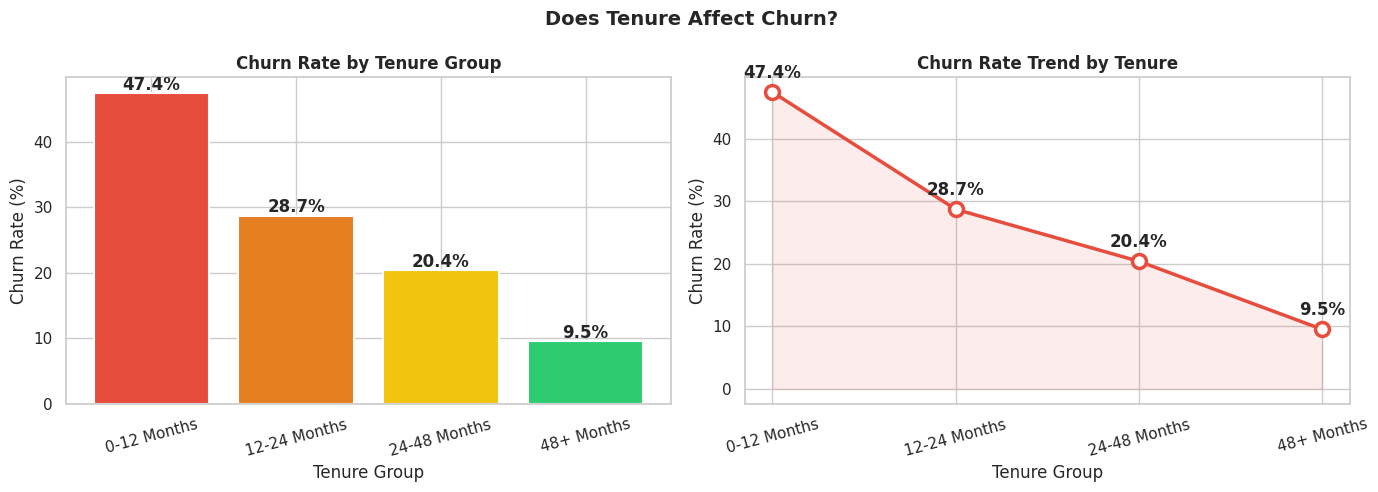

In [53]:
# Do customers who stay longer churn less?
tenure_churn = df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack() * 100

tenure_churn = tenure_churn.reindex(['0-12 Months', '12-24 Months', '24-48 Months', '48+ Months'])

print("=== Churn Rate by Tenure Group ===")
print(tenure_churn.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax1.bar(tenure_churn.index, tenure_churn['Yes'], color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Churn Rate by Tenure Group', fontweight='bold')
ax1.set_xlabel('Tenure Group')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_xticks(range(len(tenure_churn)))
ax1.set_xticklabels(tenure_churn.index, rotation=15)
for bar, val in zip(bars, tenure_churn['Yes']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

ax2.plot(tenure_churn.index, tenure_churn['Yes'], color='#e74c3c', marker='o', linewidth=2.5, markersize=10, markerfacecolor='white',
         markeredgewidth=2.5)
ax2.fill_between(range(len(tenure_churn)), tenure_churn['Yes'], alpha=0.1, color='#e74c3c')
ax2.set_title('Churn Rate Trend by Tenure', fontweight='bold')
ax2.set_xlabel('Tenure Group')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_xticks(range(len(tenure_churn)))
ax2.set_xticklabels(tenure_churn.index, rotation=15)
for i, val in enumerate(tenure_churn['Yes']):
    ax2.annotate(f'{val:.1f}%', (i, val), textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold')

plt.suptitle('Does Tenure Affect Churn?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q3_tenure_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

Analysis 3: Churn Rate by Tenure Group

Churn rate drops consistently as tenure increases:
- 0-12 months:  47.44% churn  ← CRITICAL ZONE
- 12-24 months: 28.71% churn
- 24-48 months: 20.39% churn
- 48+ months:    9.51% churn  ← LOYAL ZONE

The first 12 months is the most dangerous period for customer loss.
Almost 1 in 2 new customers leaves within their first year.

Business implication: Retention efforts should be heavily focused on
customers in their first 12 months — this is where the battle is won or lost.

In [54]:
# Which services are associated with higher churn?

services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = []
for service in services:
    churn_rate = df.groupby(service)['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
    churn_rate.columns = [service, 'ChurnRate']
    churn_rate['Service'] = service
    churn_rate.rename(columns={service: 'Value'}, inplace=True)
    service_churn.append(churn_rate)

service_df = pd.concat(service_churn, ignore_index=True)

print("=== Churn Rate by Service ===")
print(service_df.to_string(index=False))

=== Churn Rate by Service ===
              Value  ChurnRate          Service
                 No  24.926686     PhoneService
                Yes  26.709637     PhoneService
                 No  25.044248    MultipleLines
   No phone service  24.926686    MultipleLines
                Yes  28.609896    MultipleLines
                DSL  18.959108  InternetService
        Fiber optic  41.892765  InternetService
                 No   7.404980  InternetService
                 No  41.766724   OnlineSecurity
No internet service   7.404980   OnlineSecurity
                Yes  14.611194   OnlineSecurity
                 No  39.928756     OnlineBackup
No internet service   7.404980     OnlineBackup
                Yes  21.531494     OnlineBackup
                 No  39.127625 DeviceProtection
No internet service   7.404980 DeviceProtection
                Yes  22.502064 DeviceProtection
                 No  41.635474      TechSupport
No internet service   7.404980      TechSupport
          

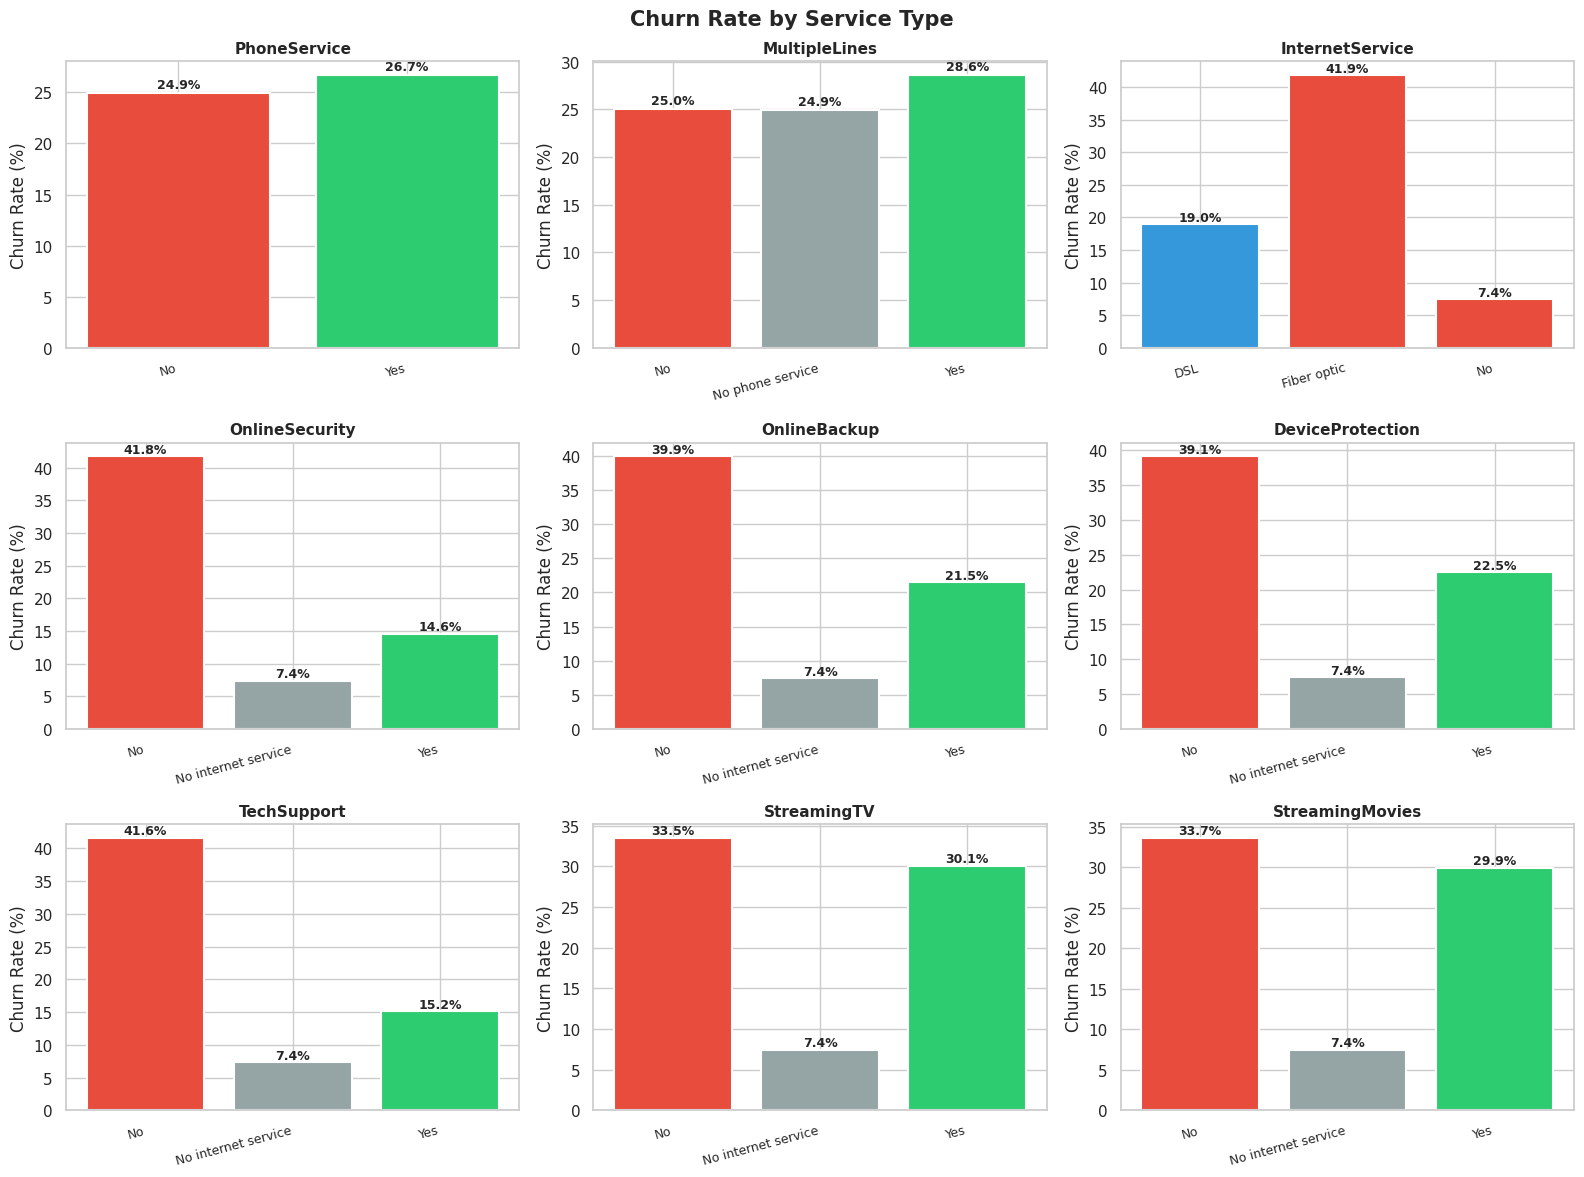

In [55]:
# Q4 — Chart: Services vs Churn Rate (warnings fixed)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors_map = {'Yes': '#2ecc71', 'No': '#e74c3c','No phone service': '#95a5a6','No internet service': '#95a5a6',
              'DSL': '#3498db', 'Fiber optic': '#e74c3c'}

for i, service in enumerate(services):
    data = service_df[service_df['Service'] == service]
    bar_colors = [colors_map.get(v, '#3498db') for v in data['Value']]

    bars = axes[i].bar(data['Value'], data['ChurnRate'], color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(service, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')

    axes[i].set_xticks(range(len(data)))
    axes[i].set_xticklabels(data['Value'], rotation=15, ha='right', fontsize=9)

    for bar, val in zip(bars, data['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center',
                     fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Service Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q4_service_churn.png', dpi=150, bbox_inches='tight')
plt.show()



Analysis 4: Churn Rate by Service Type

Internet Service is the biggest differentiator:
- Fiber optic customers churn at 41.9% — highest of all services
- DSL customers churn at 19.0% — much more stable
- Customers with no internet churn at only 7.4%

Protective add-ons dramatically reduce churn:
- Customers WITHOUT OnlineSecurity churn at 41.8% vs 14.6% WITH it
- Customers WITHOUT TechSupport churn at 41.6% vs 15.2% WITH it
- Customers WITHOUT OnlineBackup churn at 39.9% vs 21.5% WITH it

Pattern: Fiber optic customers are paying premium prices but feel
unprotected without add-ons — leading to frustration and churn.

Business implication: Bundle OnlineSecurity and TechSupport with
fiber optic plans as default, not optional add-ons.

=== Churn Rate by Payment Method ===
               PaymentMethod  ChurnRate
2           Electronic check      45.29
3               Mailed check      19.11
0  Bank transfer (automatic)      16.71
1    Credit card (automatic)      15.24


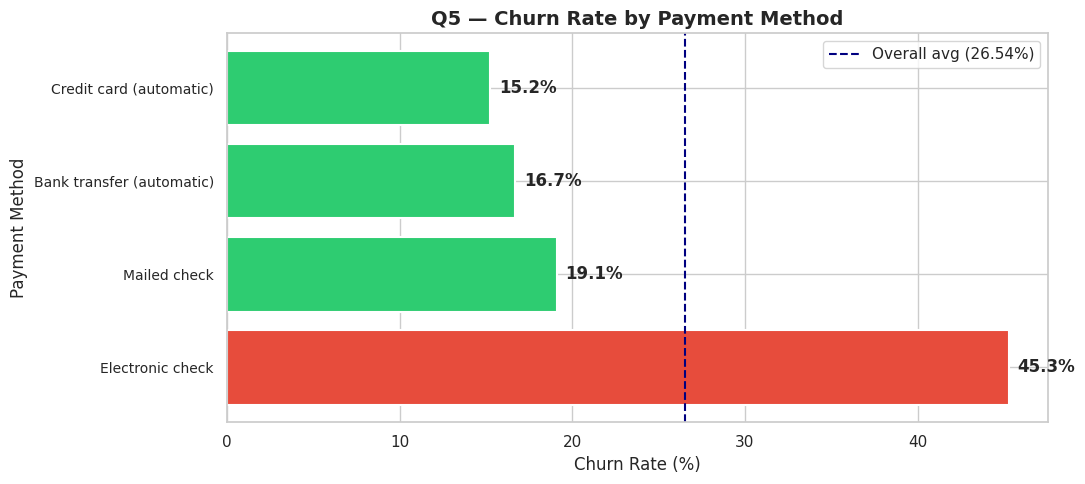

In [56]:
# Does payment method affect churn?
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).reset_index()
payment_churn.columns = ['PaymentMethod', 'ChurnRate']
payment_churn = payment_churn.sort_values('ChurnRate', ascending=False)

print("=== Churn Rate by Payment Method ===")
print(payment_churn.round(2))

fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 20
          else '#2ecc71' for x in payment_churn['ChurnRate']]

bars = ax.barh(payment_churn['PaymentMethod'], payment_churn['ChurnRate'],
               color=colors, edgecolor='white', linewidth=1.5)

ax.set_title('Q5 — Churn Rate by Payment Method',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Churn Rate (%)')
ax.set_ylabel('Payment Method')

ax.set_yticks(range(len(payment_churn)))
ax.set_yticklabels(payment_churn['PaymentMethod'], fontsize=10)

for bar, val in zip(bars, payment_churn['ChurnRate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

ax.axvline(x=26.54, color='navy', linestyle='--',
           linewidth=1.5, label='Overall avg (26.54%)')
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q5_payment_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

Analysis 5: Churn Rate by Payment Method

Electronic check customers churn at 45.29% — 3x higher than
credit card automatic customers (15.24%).

Automatic payment methods (bank transfer 16.71%, credit card 15.24%)
show significantly lower churn than manual methods.

Pattern: Customers on automatic payments are passively committed —
they've removed the monthly decision of whether to stay.
Electronic check customers make an active payment decision every month,
giving them a regular opportunity to reconsider their subscription.

Business implication: Incentivise customers to switch to automatic
payments — offer a small monthly discount for doing so.
This removes the monthly "should I stay?" decision point.

=== Revenue Impact of Churn ===
Total Revenue (all time):        $16,056,168.70
Revenue from Churned Customers:  $2,862,926.90
Revenue from Retained Customers: $13,193,241.80
Revenue Lost %:                  17.83%

=== Monthly Revenue at Risk ===
Monthly charges from churned:    $139,130.85
Monthly charges from retained:   $316,985.75
Average monthly charge (churned):  $74.44
Average monthly charge (retained): $61.27


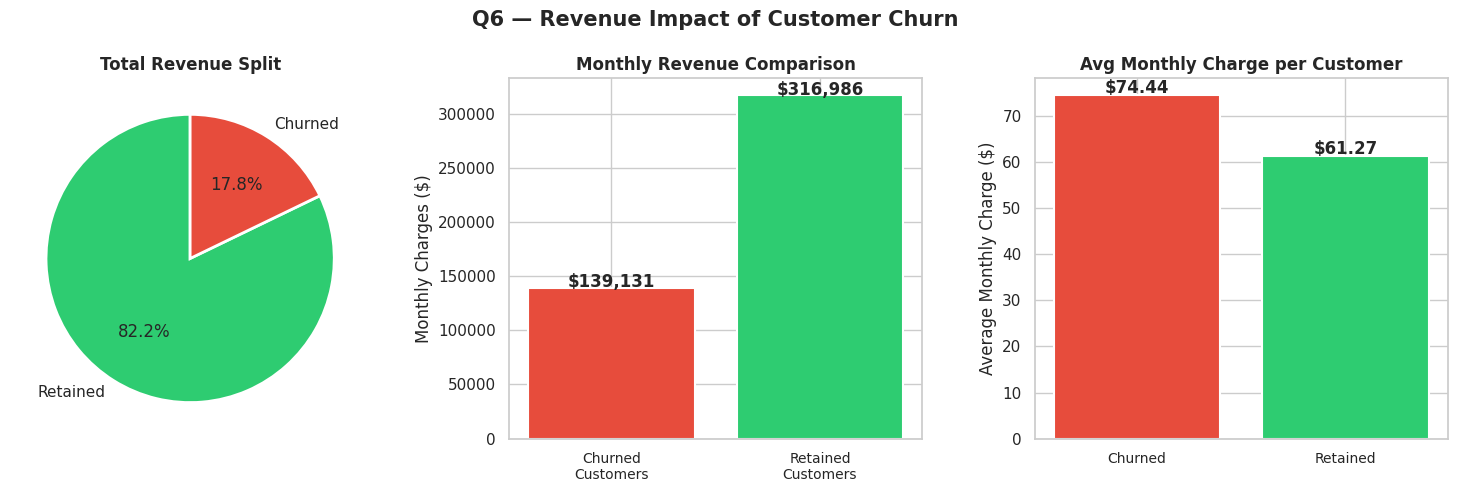

In [57]:
# What is the revenue impact of churned customers?
total_revenue = df['TotalCharges'].sum()
churned_revenue = df[df['Churn'] == 'Yes']['TotalCharges'].sum()
retained_revenue = df[df['Churn'] == 'No']['TotalCharges'].sum()

churned_monthly = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
retained_monthly = df[df['Churn'] == 'No']['MonthlyCharges'].sum()

print("=== Revenue Impact of Churn ===")
print(f"Total Revenue (all time):        ${total_revenue:,.2f}")
print(f"Revenue from Churned Customers:  ${churned_revenue:,.2f}")
print(f"Revenue from Retained Customers: ${retained_revenue:,.2f}")
print(f"Revenue Lost %:                  {churned_revenue/total_revenue*100:.2f}%")
print(f"\n=== Monthly Revenue at Risk ===")
print(f"Monthly charges from churned:    ${churned_monthly:,.2f}")
print(f"Monthly charges from retained:   ${retained_monthly:,.2f}")
print(f"Average monthly charge (churned):  ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():,.2f}")
print(f"Average monthly charge (retained): ${df[df['Churn']=='No']['MonthlyCharges'].mean():,.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].pie([retained_revenue, churned_revenue], labels=['Retained', 'Churned'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Total Revenue Split', fontweight='bold')

categories = ['Churned\nCustomers', 'Retained\nCustomers']
monthly_vals = [churned_monthly, retained_monthly]
colors = ['#e74c3c', '#2ecc71']
bars = axes[1].bar(categories, monthly_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Monthly Revenue Comparison', fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_xticks(range(len(categories)))
axes[1].set_xticklabels(categories, fontsize=10)
for bar, val in zip(bars, monthly_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'${val:,.0f}', ha='center', fontweight='bold')

avg_vals = [df[df['Churn']=='Yes']['MonthlyCharges'].mean(), df[df['Churn']=='No']['MonthlyCharges'].mean()]
bars2 = axes[2].bar(['Churned', 'Retained'], avg_vals, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[2].set_title('Avg Monthly Charge per Customer', fontweight='bold')
axes[2].set_ylabel('Average Monthly Charge ($)')
axes[2].set_xticks(range(2))
axes[2].set_xticklabels(['Churned', 'Retained'], fontsize=10)
for bar, val in zip(bars2, avg_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5, f'${val:.2f}', ha='center', fontweight='bold')

plt.suptitle('Q6 — Revenue Impact of Customer Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Telco_Churn_Dataset/charts/Q6_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()

Analysis 6: Revenue Impact of Churn

Total revenue lost to churned customers: $2,862,926.90 (17.83% of all revenue)
Monthly revenue currently at risk: $139,130.85 per month

Most alarming finding: Churned customers paid an average of $74.44/month
vs $61.27/month for retained customers.

The company is losing its HIGHEST PAYING customers at a disproportionate rate.
These are likely fiber optic customers with premium plans who feel
the price is not justified — connecting directly to Q4 findings.

Business implication: A 10% reduction in churn would save approximately
$286,000 in revenue. Retention investment is highly justified.